In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import fetch_california_housing



In [2]:
# pip install statsmodels

In [3]:
# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target



In [4]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


<Axes: >

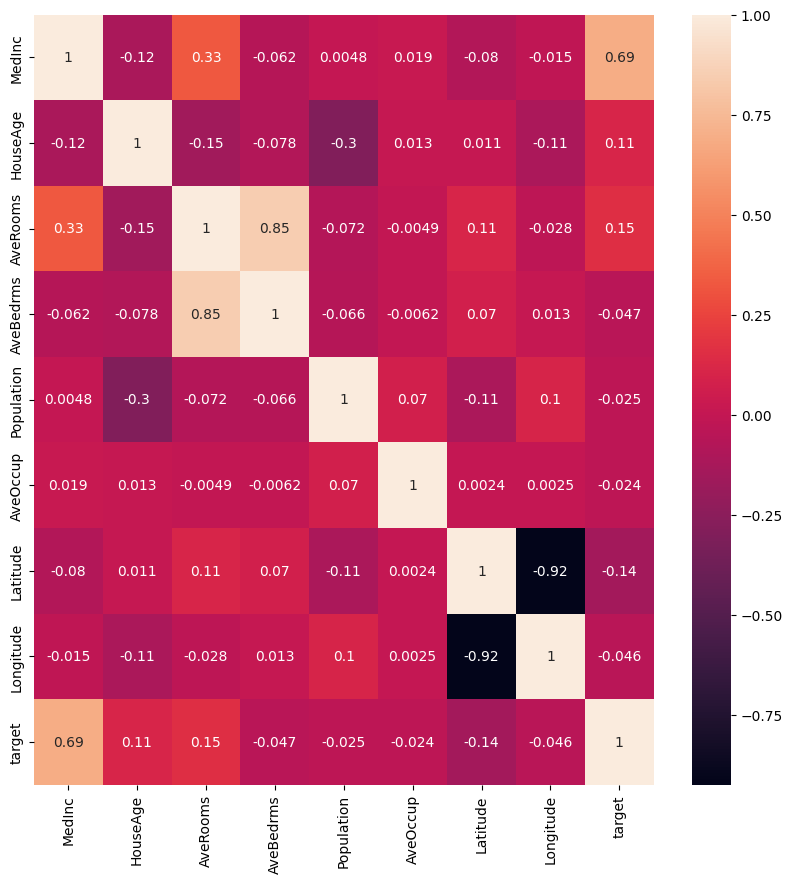

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

In [6]:
def forward_selection(data, target, significance_level=0.05):
    initial_features = []
    remaining_features = list(data.columns)
    selected_features = []
    
    while remaining_features:
        best_pval = float('inf')
        best_feature = None
        
        for feature in remaining_features:
            model_features = initial_features + [feature]
            X = sm.add_constant(data[model_features])
            y = target
            model = sm.OLS(y, X).fit()
            pval = model.pvalues[feature]
            
            if pval < best_pval:
                best_pval = pval
                best_feature = feature
        
        if best_pval < significance_level:
            initial_features.append(best_feature)
            remaining_features.remove(best_feature)
            selected_features.append((best_feature, best_pval))
            print(f"Selected: {best_feature} (p={best_pval:.4f})")
        else:
            break
    
    return initial_features


In [7]:
X = df.drop('target', axis=1)
y = df['target']

selected = forward_selection(X, y)
print("\nFinal selected features:")
print(selected)


Selected: MedInc (p=0.0000)
Selected: HouseAge (p=0.0000)
Selected: Latitude (p=0.0000)
Selected: Longitude (p=0.0000)
Selected: AveBedrms (p=0.0000)
Selected: AveRooms (p=0.0000)
Selected: AveOccup (p=0.0000)

Final selected features:
['MedInc', 'HouseAge', 'Latitude', 'Longitude', 'AveBedrms', 'AveRooms', 'AveOccup']


In [8]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Data = pd.read_csv("C:/Users/ADMIN/Desktop/FBS/Data Science/Data sets/Default.csv")